# **Imports**

In [79]:
root = "C:\\Users\\saman\\Documents\\Sensors and Technology Lab\\Magnetic Levitation\\"

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_bvp
import cv2

plt.style.use(root + "style.mplstyle")


# **Von Karman Rotating Disk Problem**

BVP solved successfully!


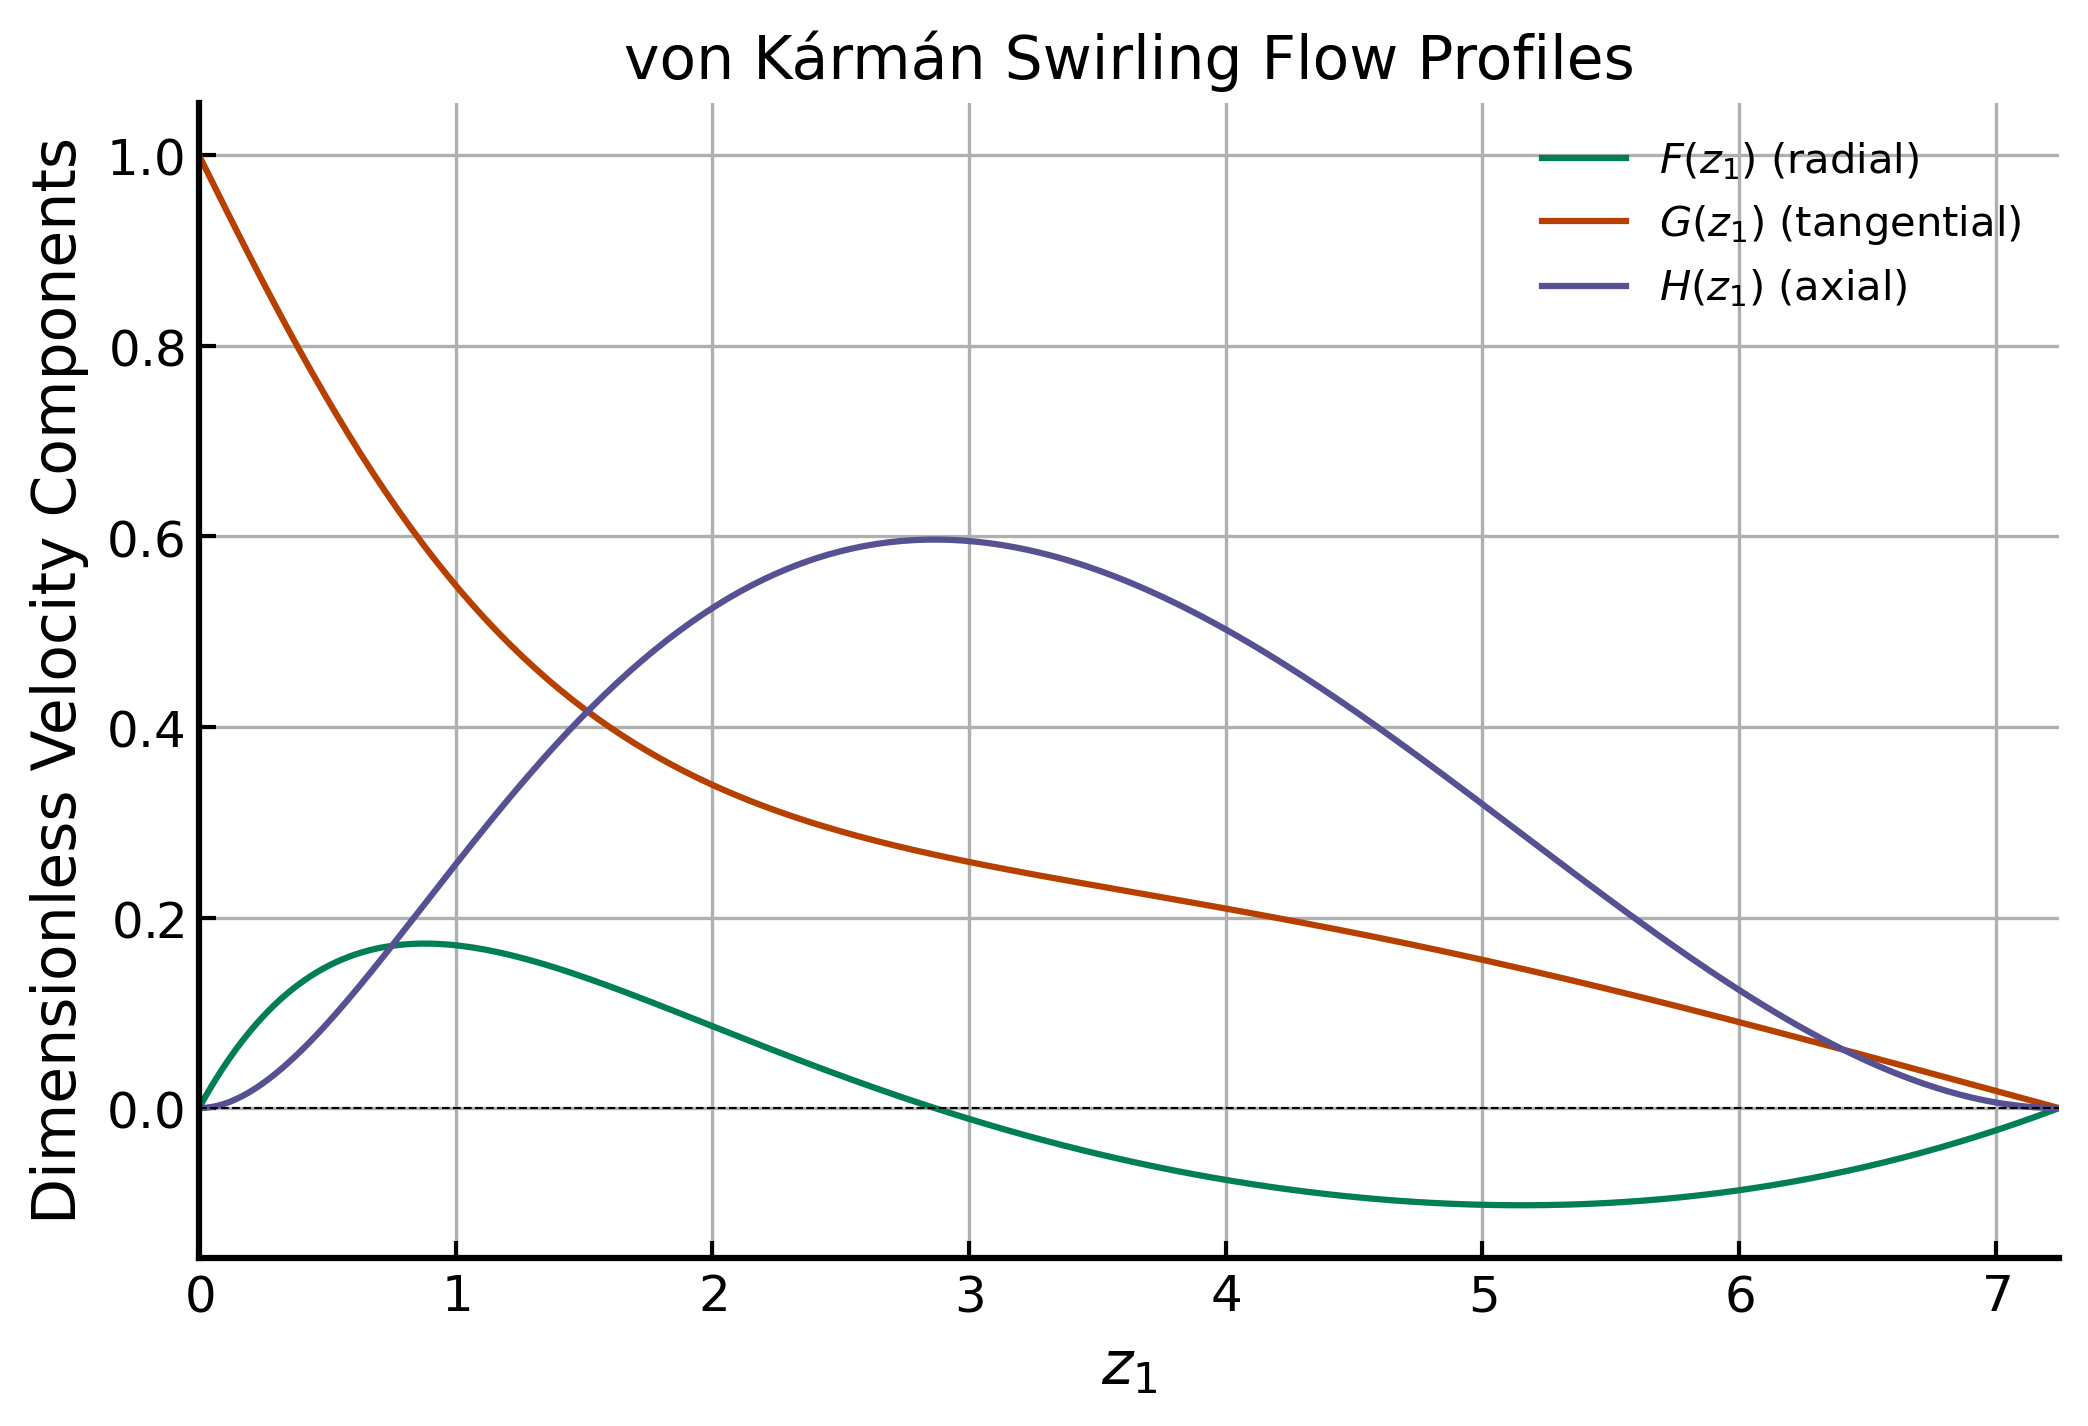

In [121]:
def von_karman_ode(z, y, p):
    K = p[0]
    F, F_prime, G, G_prime, H = y
    
    
    dF = F_prime
    dF_prime = F**2 - G**2 + F_prime * H + K**2
    dG = G_prime
    dG_prime = 2 * F * G + G_prime * H
    dH = -2 * F
    
    return np.vstack((dF, dF_prime, dG, dG_prime, dH))

# boundary conditions
def bc(ya, yb, p):
    # ya corresponds to z_1 = 0
    # yb corresponds to z_1 = s sqrt(omega/nu)
    # p is for unfixed constants, but is unused

    #return residuals
    return np.array([
        ya[0] - 0.0,  # F(0) = 0
        ya[2] - 1.0,  # G(0) = 1
        ya[4] - 0.0,  # H(0) = 0
        yb[0] - 0.0,  # F(z(s)) = 0
        yb[2] - 0.0,  # G(z(s)) = 0
        yb[4] - 0.0   # H((s))
    ])

# Setup mesh/
Omega = 1000 #angular velocity in rpm 
mu = 1.795e-5 #viscosity of the fluid
s = 0.003*np.sqrt(Omega*2*np.pi/(60*mu))
z = np.linspace(0, s, 100)

# Initial guess for state variables
y_guess = np.zeros((5, z.size))
y_guess[0] = 0.2 * z * np.exp(-z) # F guess
y_guess[2] = np.exp(-z)            # G guess
y_guess[4] = -0.5 * z              # H guess

p_guess = [s]

# 4. Solve BVP
sol = solve_bvp(von_karman_ode, bc, z, y_guess, p_guess)

if sol.success:
    print("BVP solved successfully!")
    
    # 5. Plot the solution
    z_plot = np.linspace(0, s, 300)
    y_plot = sol.sol(z_plot)

    plt.figure(figsize=(8, 5))
    plt.plot(z_plot, y_plot[0], label=r'$F(z_1)$ (radial)')
    plt.plot(z_plot, y_plot[2], label=r'$G(z_1)$ (tangential)')
    plt.plot(z_plot, -y_plot[4], label=r'$H(z_1)$ (axial)')
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.xlim(0, s)
    plt.xlabel(r'$z_1$')
    plt.ylabel('Dimensionless Velocity Components')
    plt.title('von Kármán Swirling Flow Profiles')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("BVP solver failed to converge:", sol.message)

# **Experimental Fit for Tau as a function of Gap Distance**

[[3.40590517 0.75928532]
 [0.75928532 3.01843337]]


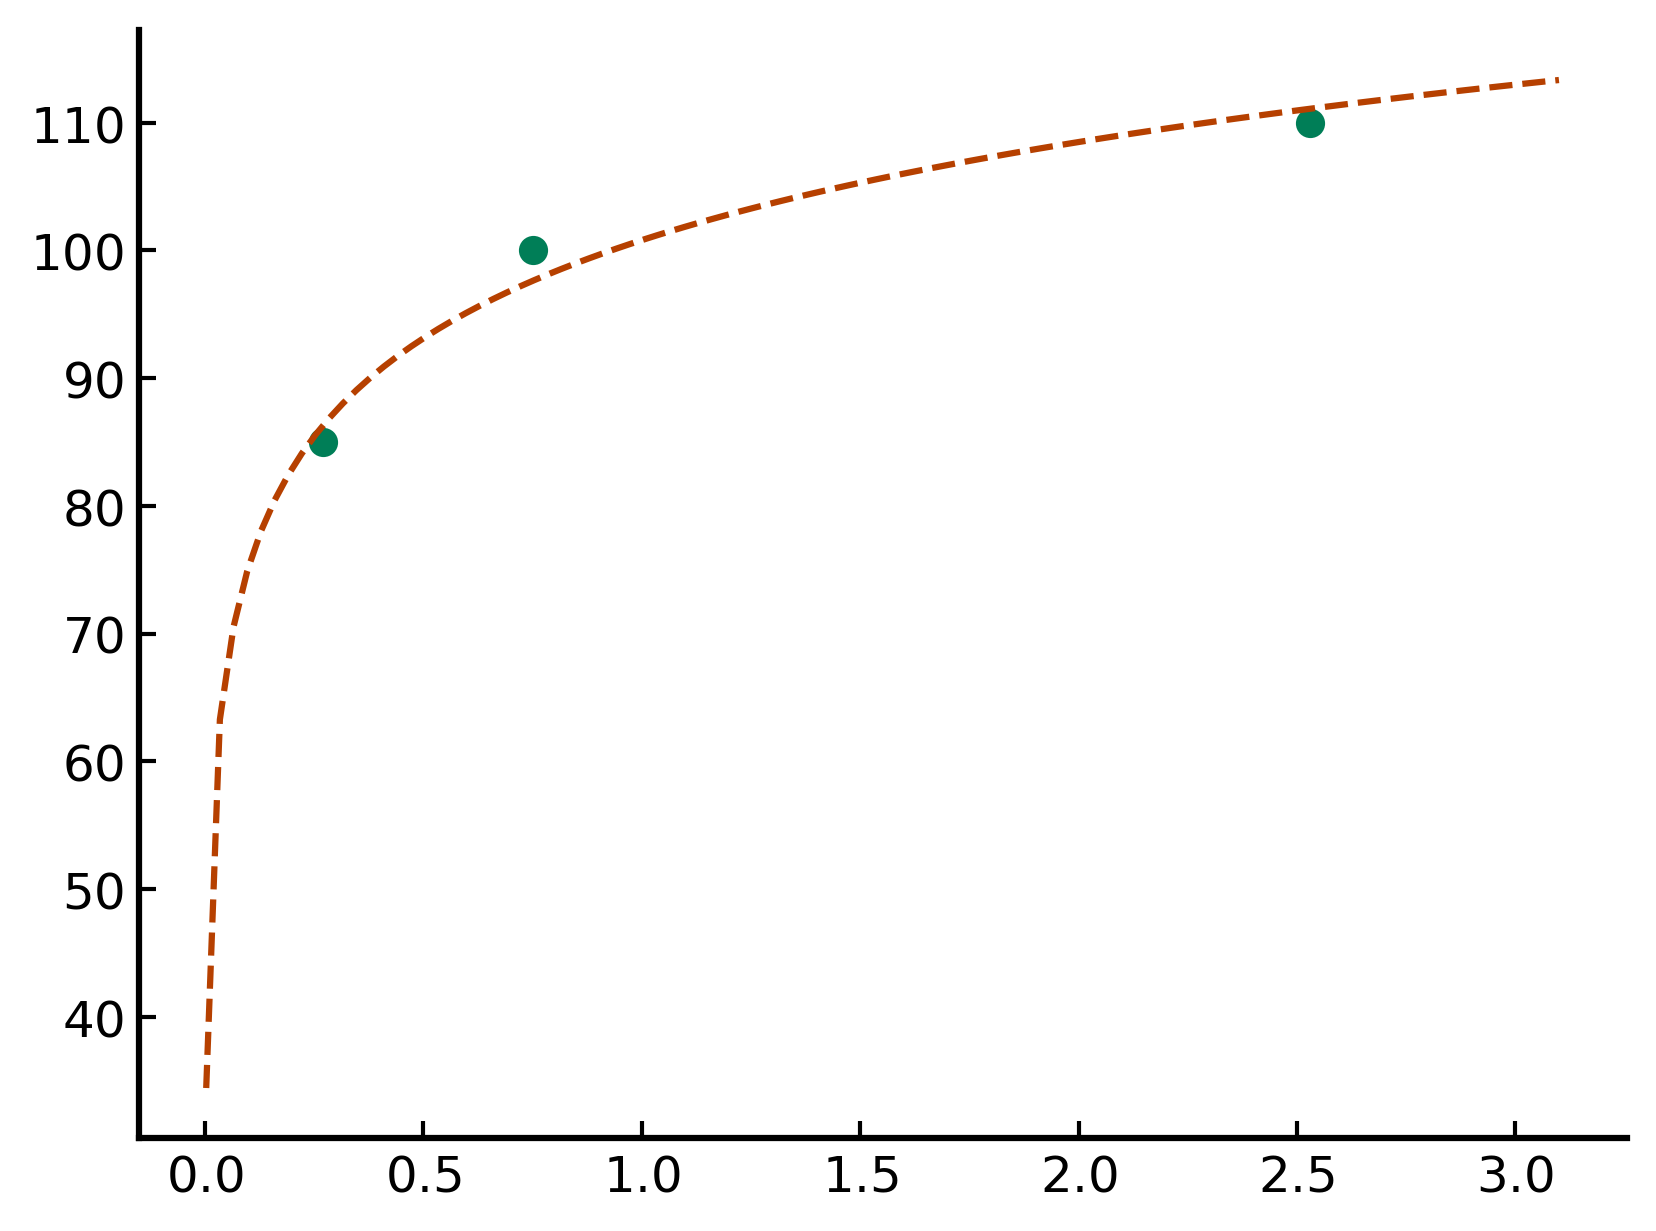

In [18]:
R = 0.00254 # meters
rho = 7500 #kg/m^3
Omega = 1000 #angular velocity in rpm 
rho_f = 1.226 #density of the fluid
mu = 1.795e-5 #viscosity of the fluid
l = 0.0105 #meters
L = 0.003175 #meters

'''
VAIBHAV: EDIT TAU_EXP, GAP_EXP ONLY, THEN RUN THIS CODE CELL AND THE NEXT ONE
'''
tau_exp = np.asarray([85, 100, 110]) #in seconds
gap_exp = np.asarray([0.27, 0.75, 2.53]) #in mm
dissipation_linexp = (np.pi**2 *rho* R**3)/(3600*tau_exp)*Omega**2



def log(x, a, b): 
    return a*np.log(x) + b

popt, pcov = curve_fit(log, gap_exp, tau_exp, p0 = (1, 1))
print(pcov)


gap_fitting = np.linspace(0.0025, 3.1, 100)
tau_fitting = popt[0]*np.log(gap_fitting) + popt[1]
dissipation_fitting = 1/tau_fitting


plt.plot(gap_exp, tau_exp, linestyle = '', marker = 'o')
plt.plot(gap_fitting, tau_fitting, linestyle = '--')
plt.show()



# **Normalized Dissipation v. Normalized Gap Distance**

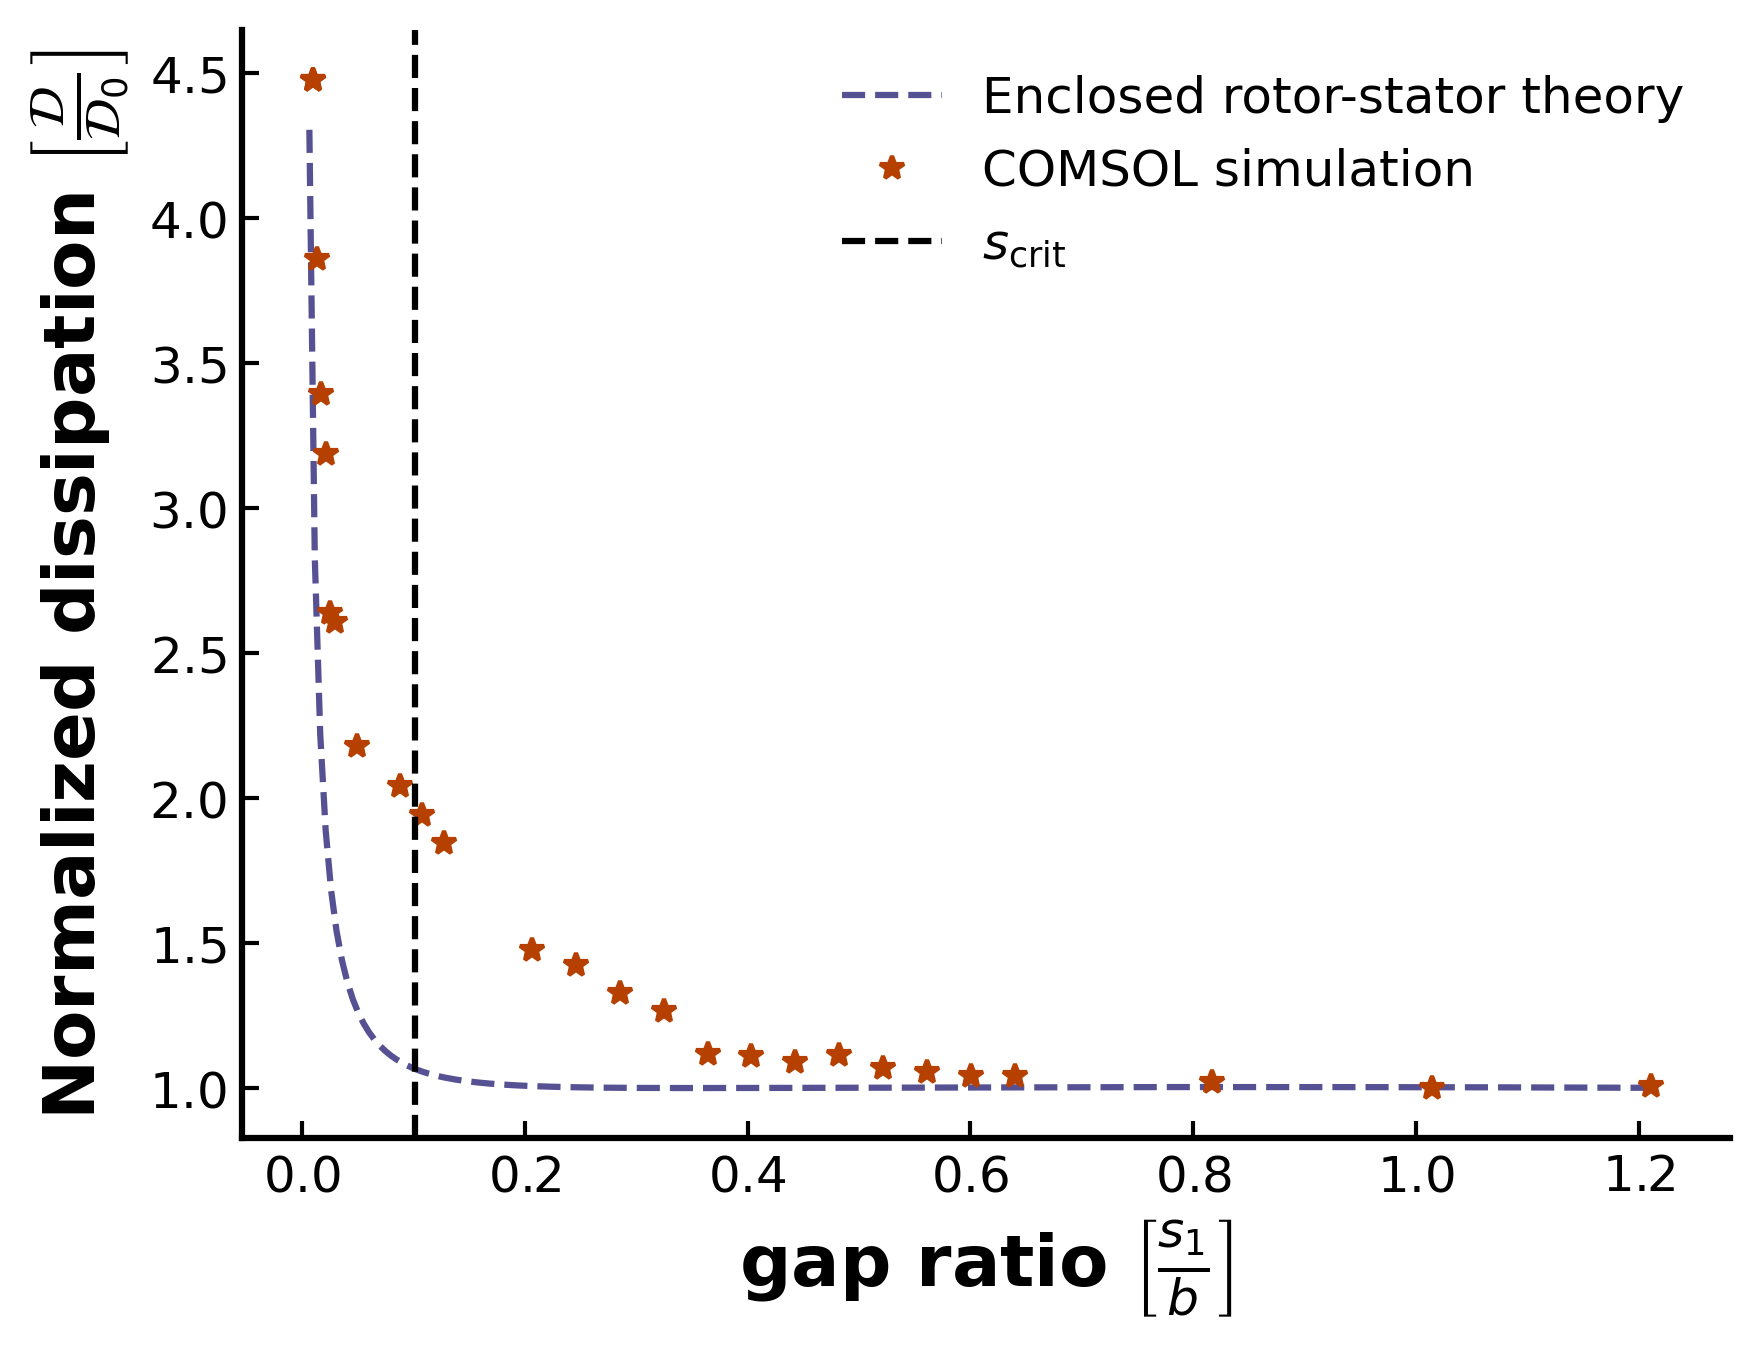

In [110]:
gap_COMSOL = 2.075  + np.asarray([-2.05, -1.95, -1.85, -1.75, -1.55, -1.45, -1.35, -1.25, -1.15, -1.05, -0.9499999999999997, -0.8499999999999996, -0.7499999999999998,
                                    -0.6499999999999997, -0.5499999999999998, -0.4499999999999997, -2.05, -2.04, -2.03, -2.02, -2.01, -2, -1.8, 1, 0.5, 0])#, -1, -0.95, -0.9, -0.85, -0.8, -0.75])
dissipation_COMSOL = np.asarray([7.276218039755276e-08, 3.54147777132402e-08, 3.319989813145014e-08, 2.999256618224352e-08, 2.397974446357202e-08, 
                                    2.315700597492343e-08, 2.161300607312653e-08, 2.059531916586093e-08, 1.818476156508958e-08, 1.805479547545832e-08,
                                    1.770094325751496e-08, 1.810964892360439e-08, 1.738181837805184e-08, 1.713697045790447e-08, 1.696140911262177e-08,
                                    1.69594542751747e-08, 7.276218039755276e-08, 6.27325979686784e-08, 5.517541944117902e-08, 5.178201911733897e-08, 
                                    4.28650162841852e-08, 4.237478948935986e-08, 3.154069141653727e-08, 1.639943102219439e-08, 1.625977604031675e-08, 1.660765723313549e-08])#, 1.660765723313549e-08, 1.660766118224957e-08,
                                    #1.660766118224957e-08, 1.660766118224956e-08, 1.660766118224957e-08, 1.660766118224957e-08])


#analytic function fitting (separate from the other stuff)
s_array = np.linspace(0.0175, 3.1, 250)/1000 # in meters
s_crit = (1.62*R)/(rho_f*Omega*R**2/mu)**(5/11) # in meters

D_disk_1 = np.where(
    s_array < s_crit,
    (mu * R**2 * Omega**2) / (s_array),
    (1.85 * np.sqrt(rho_f * mu) * R**(19/10)) / np.pi * (s_array)**0.1 * Omega**2.5
)

#churchill-usagi blending
n = 2
D_disk_1 = (((mu * R**2 * Omega**2) / (s_array))**n + ((1.85 * np.sqrt(rho_f * mu) * R**(19/10)) / np.pi * (s_array)**0.1 * Omega**2.5)**n )**(1/n)
D_shaft = 2 * mu * R * Omega**2
D_disk_2 = (1.85 * np.sqrt(rho_f * mu) * R**(19/10)) / np.pi * (l - L - s_array)**0.1 * Omega**2.5 *2

analytic_dissipation = D_disk_1 + D_disk_2 + D_shaft


plt.plot(s_array/R, analytic_dissipation/np.min(analytic_dissipation), linestyle = '--', label = 'Enclosed rotor-stator theory', c = 'C2')
#plt.plot(gap_fitting/(R*1000), dissipation_fitting/np.min(dissipation_fitting), linestyle = '--', c = 'C0')
plt.plot(gap_COMSOL/(R*1000), dissipation_COMSOL/np.min(dissipation_COMSOL), linestyle = '', marker = '*', label = 'COMSOL simulation', c = 'C1')
#plt.plot(gap_exp/(R*1000), dissipation_linexp/np.min(dissipation_linexp), linestyle = '', marker = 'o', label = 'Analytical linear damping \nfrom experiment', c = 'C0')
plt.axvline(x = s_crit/R, c = 'black', linestyle = '--', label = r'$s_\mathrm{crit}$')

plt.xlabel(r"gap ratio $\left[\frac{s_1}{b} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"Normalized dissipation $\left[\frac{\mathcal{D}}{\mathcal{D}_0} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.legend(prop={'size': 12})
plt.show()



# **Image Processing**

In [5]:
# Creating a VideoCapture object to read the video
contrast = 5 #       original: 3
brightness = 10 #    original: 15
video_path = root + 'Copied Captures\\s122_C001H001S0002.mp4'
cap = cv2.VideoCapture(video_path)

# Get video properties from the source capture
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Define the codec (e.g., 'mp4v' for .mp4 files or 'XVID' for .avi)
fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
output_path = root + 'Copied Captures\\modified_output_S0002contrast.mp4'

# Initialize the VideoWriter object
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))


while True: 
    ret, frame = cap.read()
    

    if not ret or frame is None:
        break
    
    mod_frame = cv2.addWeighted(frame, contrast, np.zeros(frame.shape, frame.dtype), 0, brightness)
    out.write(mod_frame)
    

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

out.release() 
cv2.destroyAllWindows()

---